### 0. 데이터 로딩
- CSV 파일을 불러와서 분석에 사용할 Actor(cluster_sbert) 기준으로 데이터 준비

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import ast

# CSV 파일 경로를 지정하세요
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX프로젝트/marged_output/01_Entrance_merged.csv_document.csv"  # ← 실제 파일 경로로 변경

df = pd.read_csv(CSV_PATH)
df.head()

,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,자유수다방현관시트지색 오늘 타일을 보고왔는데 눈이 핑핑돌더라구요 계속보니 이색이 이...,"['자유', '다방', '현관', '시트지', '타일', '이색', '생각', '생...",자유 다방 현관 시트지 타일 이색 생각 생각 민트 타일 들어오 현관 바닥 현관 신발...,4
1,1,인테리어 질문현관 디딤석 없는집? 안녕하세여 현관 인테리어 예정입니다 현관 디딤석이...,"['인테리어', '질문', '현관', '디디', '안녕', '현관', '인테리어',...",인테리어 질문 현관 디디 안녕 현관 인테리어 예정 현관 디디 시공 사진 디디 없애 ...,4
2,2,기타업종 구직홍보 게시판망원2동 누수탐지 주택 현관 천장 누수 망원2동 누수탐지 주...,"['기타', '업종', '구직', '홍보', '게시판', '망원', '누수', '탐...",기타 업종 구직 홍보 게시판 망원 누수 탐지 주택 현관 천장 누수 망원 누수 탐지 ...,0
3,3,자유수다방현관쪽에 전신거울 신발장쪽 현관쪽에 벽걸이 전신거울 하려고 하는데 택배왔는...,"['자유', '다방', '현관', '전신', '거울', '신발장', '현관', '벽...",자유 다방 현관 전신 거울 신발장 현관 벽걸이 전신 거울 택배 생각 아크릴 재질 거...,4
4,4,"인테리어 질문현관 덧방, 디딤석 철거 고민됩니다 ! 23년 내 매도 예정이나, 아파...","['인테리어', '질문', '현관', '디디', '철거', '고민', '매도', '...",인테리어 질문 현관 디디 철거 고민 매도 예정 아파트 순정 상태 한정 예산 셀프 준...,4


In [4]:
# tokens 컬럼이 문자열로 저장된 경우 리스트로 변환
if isinstance(df['tokens'].iloc[0], str):
    df['tokens'] = df['tokens'].apply(ast.literal_eval)

print("데이터 shape:", df.shape)
print("컬럼 목록:", df.columns.tolist())
df.head()

데이터 shape: (65299, 5)
컬럼 목록: ['doc_idx', 'text', 'tokens', 'tokens_str', 'cluster_sbert']


,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,자유수다방현관시트지색 오늘 타일을 보고왔는데 눈이 핑핑돌더라구요 계속보니 이색이 이...,"[자유, 다방, 현관, 시트지, 타일, 이색, 생각, 생각, 민트, 타일, 들어오,...",자유 다방 현관 시트지 타일 이색 생각 생각 민트 타일 들어오 현관 바닥 현관 신발...,4
1,1,인테리어 질문현관 디딤석 없는집? 안녕하세여 현관 인테리어 예정입니다 현관 디딤석이...,"[인테리어, 질문, 현관, 디디, 안녕, 현관, 인테리어, 예정, 현관, 디디, 시...",인테리어 질문 현관 디디 안녕 현관 인테리어 예정 현관 디디 시공 사진 디디 없애 ...,4
2,2,기타업종 구직홍보 게시판망원2동 누수탐지 주택 현관 천장 누수 망원2동 누수탐지 주...,"[기타, 업종, 구직, 홍보, 게시판, 망원, 누수, 탐지, 주택, 현관, 천장, ...",기타 업종 구직 홍보 게시판 망원 누수 탐지 주택 현관 천장 누수 망원 누수 탐지 ...,0
3,3,자유수다방현관쪽에 전신거울 신발장쪽 현관쪽에 벽걸이 전신거울 하려고 하는데 택배왔는...,"[자유, 다방, 현관, 전신, 거울, 신발장, 현관, 벽걸이, 전신, 거울, 택배,...",자유 다방 현관 전신 거울 신발장 현관 벽걸이 전신 거울 택배 생각 아크릴 재질 거...,4
4,4,"인테리어 질문현관 덧방, 디딤석 철거 고민됩니다 ! 23년 내 매도 예정이나, 아파...","[인테리어, 질문, 현관, 디디, 철거, 고민, 매도, 예정, 아파트, 순정, 상태...",인테리어 질문 현관 디디 철거 고민 매도 예정 아파트 순정 상태 한정 예산 셀프 준...,4


In [5]:
# Actor(cluster_sbert) 기준 군집 수 확인
print("cluster_sbert 군집별 문서 수:")
print(df['cluster_sbert'].value_counts().sort_index())

cluster_sbert 군집별 문서 수:
cluster_sbert
0    13964
1     9536
2    16562
3     4226
4    21011
Name: count, dtype: int64


### 1. LDA를 위한 데이터 전처리
- 특정 Actor(cluster_sbert)를 선택하여 단어사전 생성 및 BOW 변환

In [6]:
# 분석할 Actor 번호 설정 (cluster_sbert 값 중 하나)
TARGET_ACTOR = 2  # ← 분석할 Actor 번호로 변경

df_actor = df[df['cluster_sbert'] == TARGET_ACTOR].copy()
print(f"Actor {TARGET_ACTOR} 문서 수:", df_actor.shape[0])
df_actor.head()

Actor 2 문서 수: 16562


,doc_idx,text,tokens,tokens_str,cluster_sbert
83,83,내가만든작품말머리내가 만든 작품현관 콘솔 현관 한쪽 벽면의 조금 들어간 공간을 위한...,"[만들, 작품, 머리, 만들, 작품, 현관, 콘솔, 현관, 한쪽, 벽면, 들어가, ...",만들 작품 머리 만들 작품 현관 콘솔 현관 한쪽 벽면 들어가 공간 위하 현관 콘솔 ...,2
86,86,인테리어사진 모음우리집 현관 자랑해봅니다.. 추억속의 공간..철거 전 현관 ai로 ...,"[인테리어, 사진, 모으, 현관, 자랑, 추억, 공간, 철거, 현관, 기존, 지우,...",인테리어 사진 모으 현관 자랑 추억 공간 철거 현관 기존 지우 신축 현관 철거 디디...,2
130,130,집소품인테리어커피현관앞 신발장 주변정리 중 어제. 아들넘님 컴터책상으로 사용하던 제...,"[소품, 인테리어, 커피, 현관, 신발장, 주변, 정리, 아들, 책상, 사용, 화장...",소품 인테리어 커피 현관 신발장 주변 정리 아들 책상 사용 화장대 서랍 내보내 현관...,2
133,133,로봇청소기 자유스토리드리미 l40s 현관에 자꾸 떨어져요.. 10번방으로 되어있는곳...,"[로봇, 청소기, 자유, 스토리, 현관, 떨어지, 현관, 추락, 걸치, 가상, 세우...",로봇 청소기 자유 스토리 현관 떨어지 현관 추락 걸치 가상 세우 추락 현관 인식 모...,2
149,149,일상여행수다현관 탈취제 효과 좋은 거 있나요? 현관에 들어서면 신발 냄새가 심하게 ...,"[일상, 여행, 수다, 현관, 탈취제, 효과, 현관, 들어서, 신발, 냄새, 심하,...",일상 여행 수다 현관 탈취제 효과 현관 들어서 신발 냄새 심하 현관 탈취제 종류 효...,2


In [7]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.1 MB/s eta 0:00:00


In [8]:
from gensim.corpora import Dictionary

# tokens 컬럼을 리스트로 변환
all_documents = list(df_actor['tokens'])

# 단어사전 구축
word_dict = Dictionary(all_documents)
print("단어사전 크기:", len(word_dict))
print("샘플 토큰:", list(word_dict.token2id.items())[:10])

단어사전 크기: 24273
샘플 토큰: [('가공', 0), ('가운데', 1), ('각도', 2), ('곡면', 3), ('곡선', 4), ('공간', 5), ('길이', 6), ('다리', 7), ('대패', 8), ('들어가', 9)]


In [9]:
# 전체 문서에 BOW 변환
corpus = [word_dict.doc2bow(doc) for doc in all_documents]

# 샘플 확인
print("원문 토큰:", all_documents[0])
print("BOW 변환:", corpus[0])

원문 토큰: ['만들', '작품', '머리', '만들', '작품', '현관', '콘솔', '현관', '한쪽', '벽면', '들어가', '공간', '위하', '현관', '콘솔', '상판', '곡선', '서랍', '곡면', '다리', '사선', '대패', '작업', '만들', '서랍', '가운데', '제외', '양쪽', '서랍', '서랍', '길이', '차이', '서랍', '주먹', '가공', '각도', '서랍', '손잡이']
BOW 변환: [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 3), (11, 1), (12, 1), (13, 1), (14, 1), (15, 6), (16, 1), (17, 1), (18, 1), (19, 1), (20, 2), (21, 1), (22, 1), (23, 1), (24, 2), (25, 1), (26, 3)]


### 2. 토픽 수 선정
- perplexity와 coherence를 비교하여 최적 토픽 수 결정

In [10]:
!pip install new_value_analysis -q

  0%|          | 0/8 [00:00<?, ?it/s]

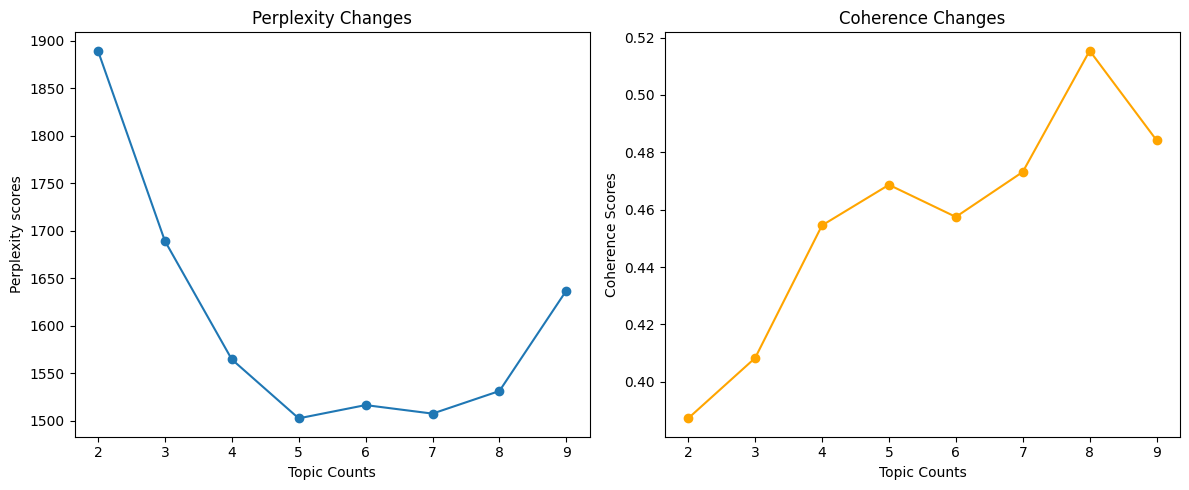

In [11]:
from new_value_analysis.action_finder import lda_perplexity_coherence_plot

lda_perplexity_coherence_plot(
    corpus=corpus,
    word_dict=word_dict,
    all_documents=all_documents,
    topic_range=range(2, 10),   # 2~9개 토픽 수 비교
    passes=10,
    iterations=20,
    random_state=2026,
    fixed_topn=10,
    figsize=(12, 5)
)
# perplexity 낮을수록 좋고, coherence 높을수록 좋음
# 그래프를 보고 아래 TOPIC_NUM을 결정하세요

### 3. LDA 모델 학습 및 Action 번호 매칭

In [12]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import gensim

TOPIC_NUM = 5  # ← 위 그래프를 보고 결정한 토픽 수로 변경

ldamodel = gensim.models.ldamodel.LdaModel(
    corpus,
    id2word=word_dict,
    num_topics=TOPIC_NUM,
    passes=10,
    iterations=20,
    random_state=2026
)

# 토픽별 주요 단어 확인
ldamodel.print_topics(num_words=10)

[(0,
  '0.063*"신발장" + 0.035*"신발" + 0.033*"현관" + 0.022*"정리" + 0.020*"공간" + 0.017*"수납" + 0.014*"제품" + 0.012*"사용" + 0.011*"가구" + 0.010*"인테리어"'),
 (1,
  '0.090*"신발장" + 0.037*"냄새" + 0.033*"금지" + 0.032*"좌표" + 0.032*"리플" + 0.032*"쪽지" + 0.022*"재생" + 0.020*"사용" + 0.013*"제거" + 0.012*"설정"'),
 (2,
  '0.059*"정리" + 0.037*"청소" + 0.037*"현관" + 0.018*"신발장" + 0.018*"신발" + 0.013*"비우" + 0.011*"자유" + 0.011*"오늘" + 0.010*"버리" + 0.008*"아이"'),
 (3,
  '0.051*"신발장" + 0.021*"완료" + 0.019*"드림" + 0.018*"판매" + 0.017*"드리" + 0.017*"나누" + 0.011*"무료" + 0.009*"사용" + 0.009*"사진" + 0.009*"머리"'),
 (4,
  '0.011*"아이" + 0.008*"시간" + 0.006*"생각" + 0.006*"아기" + 0.005*"드리" + 0.005*"감사" + 0.005*"이모" + 0.005*"엄마" + 0.005*"관리" + 0.004*"이사"')]

In [13]:
from new_value_analysis.action_finder import assign_action_number

action_number_assignment = assign_action_number(ldamodel, corpus=corpus)
print("Action 번호 할당 결과 샘플:", action_number_assignment[:10])

Action 번호 할당 결과 샘플: [0, 0, 2, 2, 1, 0, 2, 4, 2, 2]


In [14]:
print(f"데이터프레임 행 수: {len(df_actor)}")
print(f"새 데이터 리스트 수: {len(action_number_assignment)}")
print(f"차이: {len(df_actor) - len(action_number_assignment)}개 부족")

데이터프레임 행 수: 16562
새 데이터 리스트 수: 16562
차이: 0개 부족


In [15]:
# action 번호를 새로운 컬럼으로 추가
df_actor = df_actor.copy()
df_actor['action_cluster'] = action_number_assignment

print("Action별 문서 수:")
print(df_actor['action_cluster'].value_counts().sort_index())
df_actor.head()

Action별 문서 수:
action_cluster
0    2521
1    1300
2    7954
3    2925
4    1862
Name: count, dtype: int64


,doc_idx,text,tokens,tokens_str,cluster_sbert,action_cluster
83,83,내가만든작품말머리내가 만든 작품현관 콘솔 현관 한쪽 벽면의 조금 들어간 공간을 위한...,"[만들, 작품, 머리, 만들, 작품, 현관, 콘솔, 현관, 한쪽, 벽면, 들어가, ...",만들 작품 머리 만들 작품 현관 콘솔 현관 한쪽 벽면 들어가 공간 위하 현관 콘솔 ...,2,0
86,86,인테리어사진 모음우리집 현관 자랑해봅니다.. 추억속의 공간..철거 전 현관 ai로 ...,"[인테리어, 사진, 모으, 현관, 자랑, 추억, 공간, 철거, 현관, 기존, 지우,...",인테리어 사진 모으 현관 자랑 추억 공간 철거 현관 기존 지우 신축 현관 철거 디디...,2,0
130,130,집소품인테리어커피현관앞 신발장 주변정리 중 어제. 아들넘님 컴터책상으로 사용하던 제...,"[소품, 인테리어, 커피, 현관, 신발장, 주변, 정리, 아들, 책상, 사용, 화장...",소품 인테리어 커피 현관 신발장 주변 정리 아들 책상 사용 화장대 서랍 내보내 현관...,2,2
133,133,로봇청소기 자유스토리드리미 l40s 현관에 자꾸 떨어져요.. 10번방으로 되어있는곳...,"[로봇, 청소기, 자유, 스토리, 현관, 떨어지, 현관, 추락, 걸치, 가상, 세우...",로봇 청소기 자유 스토리 현관 떨어지 현관 추락 걸치 가상 세우 추락 현관 인식 모...,2,2
149,149,일상여행수다현관 탈취제 효과 좋은 거 있나요? 현관에 들어서면 신발 냄새가 심하게 ...,"[일상, 여행, 수다, 현관, 탈취제, 효과, 현관, 들어서, 신발, 냄새, 심하,...",일상 여행 수다 현관 탈취제 효과 현관 들어서 신발 냄새 심하 현관 탈취제 종류 효...,2,1


### 4. pyLDAvis 시각화

In [16]:
!pip install pyldavis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 44.3 MB/s eta 0:00:00


In [17]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

prepared_data = gensimvis.prepare(ldamodel, corpus, word_dict)
pyLDAvis.display(prepared_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
# HTML로 저장
pyLDAvis.save_html(prepared_data, f"./ldavis_actor{TARGET_ACTOR}_action.html")
print(f"저장 완료: ldavis_actor{TARGET_ACTOR}_action.html")

저장 완료: ldavis_actor2_action.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 5. pyLDAvis 기준으로 Action 번호 재매핑
- LDA 모델의 토픽 인덱스와 pyLDAvis의 토픽 인덱스가 불일치할 수 있음
- 아래 매핑을 pyLDAvis 시각화 결과를 보고 직접 수정하세요

In [19]:
# LDA 토픽 번호 확인
print("LDA 토픽 번호 및 주요 단어:")
ldamodel.print_topics(num_words=10)

LDA 토픽 번호 및 주요 단어:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[(0,
  '0.063*"신발장" + 0.035*"신발" + 0.033*"현관" + 0.022*"정리" + 0.020*"공간" + 0.017*"수납" + 0.014*"제품" + 0.012*"사용" + 0.011*"가구" + 0.010*"인테리어"'),
 (1,
  '0.090*"신발장" + 0.037*"냄새" + 0.033*"금지" + 0.032*"좌표" + 0.032*"리플" + 0.032*"쪽지" + 0.022*"재생" + 0.020*"사용" + 0.013*"제거" + 0.012*"설정"'),
 (2,
  '0.059*"정리" + 0.037*"청소" + 0.037*"현관" + 0.018*"신발장" + 0.018*"신발" + 0.013*"비우" + 0.011*"자유" + 0.011*"오늘" + 0.010*"버리" + 0.008*"아이"'),
 (3,
  '0.051*"신발장" + 0.021*"완료" + 0.019*"드림" + 0.018*"판매" + 0.017*"드리" + 0.017*"나누" + 0.011*"무료" + 0.009*"사용" + 0.009*"사진" + 0.009*"머리"'),
 (4,
  '0.011*"아이" + 0.008*"시간" + 0.006*"생각" + 0.006*"아기" + 0.005*"드리" + 0.005*"감사" + 0.005*"이모" + 0.005*"엄마" + 0.005*"관리" + 0.004*"이사"')]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
# ↓ pyLDAvis 시각화 결과를 보고 매핑 딕셔너리를 직접 수정하세요
# 예시: LDA 토픽 0 → pyLDAvis 토픽 2, LDA 토픽 1 → pyLDAvis 토픽 3, ...
topic_mapping = {
    0: 2,
    1: 5,
    2: 1,
    3: 4,
    4: 3
}

df_actor['action_cluster'] = df_actor['action_cluster'].map(topic_mapping)

print("재매핑 후 Action별 문서 수:")
print(df_actor['action_cluster'].value_counts().sort_index())

재매핑 후 Action별 문서 수:
action_cluster
1    7954
2    2521
3    1862
4    2925
5    1300
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [21]:
# 결과 저장 (pickle)
SAVE_PATH = f"./cluster_df_{TARGET_ACTOR}_action__.pkl"
df_actor.to_pickle(SAVE_PATH)
print(f"저장 완료: {SAVE_PATH}")
df_actor.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

저장 완료: ./cluster_df_2_action__.pkl


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,doc_idx,text,tokens,tokens_str,cluster_sbert,action_cluster
83,83,내가만든작품말머리내가 만든 작품현관 콘솔 현관 한쪽 벽면의 조금 들어간 공간을 위한...,"[만들, 작품, 머리, 만들, 작품, 현관, 콘솔, 현관, 한쪽, 벽면, 들어가, ...",만들 작품 머리 만들 작품 현관 콘솔 현관 한쪽 벽면 들어가 공간 위하 현관 콘솔 ...,2,2
86,86,인테리어사진 모음우리집 현관 자랑해봅니다.. 추억속의 공간..철거 전 현관 ai로 ...,"[인테리어, 사진, 모으, 현관, 자랑, 추억, 공간, 철거, 현관, 기존, 지우,...",인테리어 사진 모으 현관 자랑 추억 공간 철거 현관 기존 지우 신축 현관 철거 디디...,2,2
130,130,집소품인테리어커피현관앞 신발장 주변정리 중 어제. 아들넘님 컴터책상으로 사용하던 제...,"[소품, 인테리어, 커피, 현관, 신발장, 주변, 정리, 아들, 책상, 사용, 화장...",소품 인테리어 커피 현관 신발장 주변 정리 아들 책상 사용 화장대 서랍 내보내 현관...,2,1
133,133,로봇청소기 자유스토리드리미 l40s 현관에 자꾸 떨어져요.. 10번방으로 되어있는곳...,"[로봇, 청소기, 자유, 스토리, 현관, 떨어지, 현관, 추락, 걸치, 가상, 세우...",로봇 청소기 자유 스토리 현관 떨어지 현관 추락 걸치 가상 세우 추락 현관 인식 모...,2,1
149,149,일상여행수다현관 탈취제 효과 좋은 거 있나요? 현관에 들어서면 신발 냄새가 심하게 ...,"[일상, 여행, 수다, 현관, 탈취제, 효과, 현관, 들어서, 신발, 냄새, 심하,...",일상 여행 수다 현관 탈취제 효과 현관 들어서 신발 냄새 심하 현관 탈취제 종류 효...,2,5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag